# Chinese Chess Recognition System
## Model Comparison: CNN vs YOLO + System Pipeline

Notebook này trình bày:
1. **Pipeline xử lý** của hệ thống nhận diện cờ tướng theo thời gian thực
2. **So sánh hai model**: CNN (`new_model_v2.h5`) và YOLO (`weights.pt`)

In [71]:
import os, sys, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patches as FancyBbox
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.gridspec import GridSpec
import matplotlib.patheffects as pe

# --- Paths ---
BASE_DIR   = os.path.abspath('.')
H5_PATH    = os.path.join(BASE_DIR, 'h5_file', 'new_model_v2.h5')
ONNX_PATH  = os.path.join(BASE_DIR, 'chinese_chess_model.onnx')
YOLO_PATH  = os.path.join(BASE_DIR, 'weights.pt')
VALID_DIR  = os.path.join(BASE_DIR, 'Dataset', 'valid')
TEST_IMG   = os.path.join(BASE_DIR, 'Test_Image', 'Step 0.png')

print('Base dir :', BASE_DIR)
print('H5 exists :', os.path.exists(H5_PATH))
print('ONNX exists:', os.path.exists(ONNX_PATH))
print('YOLO exists:', os.path.exists(YOLO_PATH))
print('Valid dir  :', os.path.exists(VALID_DIR))
print('Step 0.png :', os.path.exists(TEST_IMG))

Base dir : d:\work\chinese_chessh_test
H5 exists : True
ONNX exists: True
YOLO exists: True
Valid dir  : True
Step 0.png : True


---
# Phần 1 — Pipeline Xử Lý Hệ Thống

Sơ đồ dưới đây mô tả toàn bộ luồng xử lý từ lúc camera bắt đầu đến khi hệ thống xác nhận một nước đi hợp lệ.



## 1. Khởi động & Step 0 — Canh bàn cờ tự động
- Mở camera/video (`real_time_test.py:881`)
- Hiển thị khung hình để user dùng **I/J/K/L/+/-/F** canh bàn cờ vào ROI
- Tự động chụp Step 0 khi frame ổn định đủ **2 giây** (không còn chuyển động)
- Dùng `HoughCircles` trên Step 0 để xác định `begin_point`, `GRID_WIDTH_HORI`, `GRID_WIDTH_VERTI` → tọa độ từng ô cờ

## 2. Khởi tạo trạng thái bàn cờ ban đầu
- `init_board_state()` gọi YOLO detect trên Step 0
- Tạo `board_state_map = dict {(col, row): piece_label}` — bản đồ quân cờ hiện tại

## 3. Vòng lặp chính — Motion Detection
- Mỗi frame: crop ROI → resize về **480×480**
- So sánh với frame trước bằng `cv2.absdiff` → tính `motion_score`
- Nếu `motion_score > STABLE_DIFF_THRESHOLD`: bàn có người đang di chuyển → `motion_active = True`, reset `stable_count`
- Nếu ngược lại: `stable_count += 1`

## 4. Trigger Detection bất đồng bộ
- Khi `motion_active == True` và `stable_count >= STABLE_FRAMES_REQUIRED` (≈0.3s ổn định sau khi di chuyển): spawn background thread chạy `PiecesChangeDetection()`
- Thread gửi kết quả vào queue → main loop nhận non-blocking, không bị đơ

## 5. Nhận diện nước đi — PiecesChangeDetection()

```
frame hiện tại
    ↓
changeDetection() → tìm vùng thay đổi (bounding rect của diff)
    ↓
detect_board_map() → YOLO inference toàn bàn → prev_map vs curr_map
    ↓
infer_move_from_states() → so sánh 2 map, tìm (begin, end)
    ↓
is_legal_move() → kiểm tra luật cờ tướng
    ↓
Cập nhật board_state_map
```

## 6. detect_board_map() — Nhận diện bàn cờ bằng YOLO
- YOLO (`weights.pt`) chạy inference toàn ảnh với `conf=0.12`
- Mỗi detection: snap tâm về ô lưới `(bx, by)` gần nhất qua `point_to_board_xy()`
- `correct_label_by_position()`: nếu `r_shi/b_shi` (Sĩ) nằm ngoài cung → đổi thành `r_bing/b_zu`
- **Stabilization**: nếu nhãn đổi so với frame trước nhưng confidence thấp → giữ nhãn cũ

## 7. infer_move_from_states() — Suy luận nước đi
- Tìm ô bị mất quân (vacated) và ô mới có quân (occupied/changed)
- Dùng `_score_move_candidate()` để chấm điểm từng cặp `(begin→end)` dựa vào luật di chuyển của từng loại quân
- Chọn cặp điểm cao nhất → đó là nước đi

## 8. Kiểm tra luật cờ tướng
`is_legal_move()` kiểm tra theo từng loại quân:
- **Mã (ma)**: đi hình chữ L
- **Tượng (xiang)**: đi chéo 2 ô
- **Sĩ (shi)**: đi chéo 1 ô trong cung
- **Xe, Pháo (ju/pao)**: đi thẳng
- **Tốt (bing/zu)**: đi về phía trước, sau khi qua hà mới được đi ngang
- **Lượt đi**: kiểm tra đúng màu quân

## 9. Lưu kết quả
- Nếu hợp lệ: lưu `Step N+1.png`, tăng step, đổi lượt `isRed`
- Vẽ mũi tên lên ảnh + lưu vào `Move_Captures/step_NNN_PieceName_LEGAL/ILLEGAL.png`
- Nếu bất hợp lệ: in cảnh báo, không tăng bước, cập nhật lại Step 0 để tránh phát hiện lại cùng nước đi

---

## Sơ đồ file chính

| File | Vai trò |
|------|---------|
| `real_time_test.py` | Pipeline chính: motion detection, vòng lặp, điều phối |
| `piece_detector.py` | Wrapper YOLO: detect toàn bàn, classify từng ô |
| `AdjustCameraLocation.py` | Địa chỉ IP camera |
| `weights.pt` | Model YOLO đã train nhận diện 14 loại quân cờ |

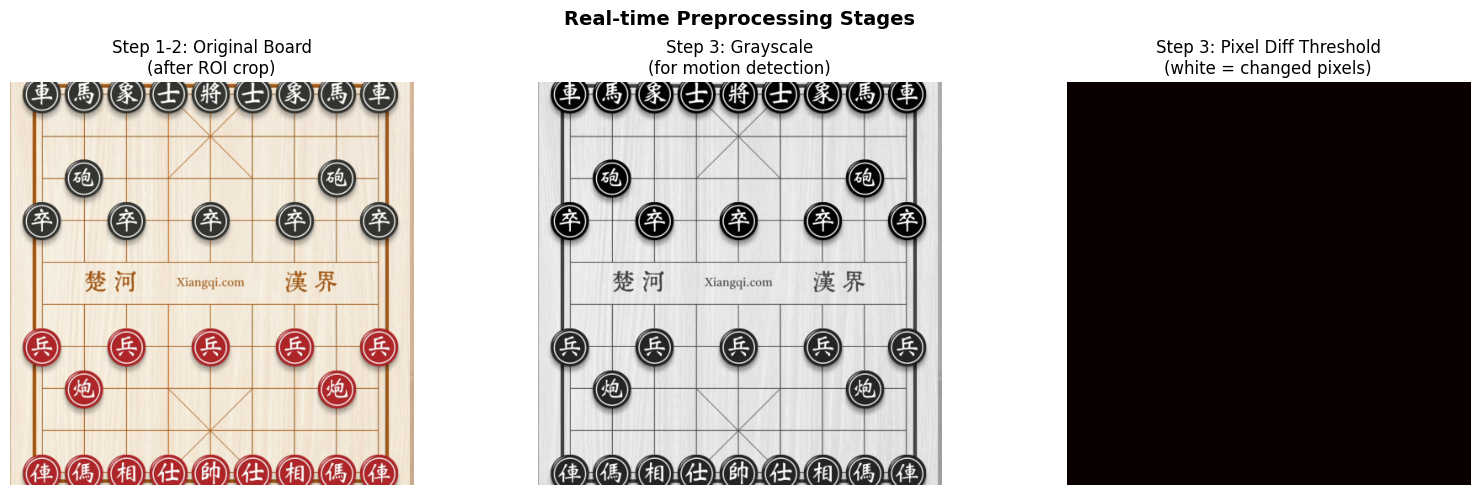

In [72]:
# Visualize actual processing steps on a real board image
import cv2
import numpy as np

if os.path.exists(TEST_IMG):
    img_bgr = cv2.imread(TEST_IMG)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Simulate motion diff (use random noise for demo)
    rng = np.random.default_rng(42)
    prev_gray = gray.astype(np.int32) + rng.integers(-15, 15, gray.shape)
    prev_gray = np.clip(prev_gray, 0, 255).astype(np.uint8)
    diff = cv2.absdiff(gray, prev_gray)
    _, thresh = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(img_rgb)
    axes[0].set_title('Step 1-2: Original Board\n(after ROI crop)', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(gray, cmap='gray')
    axes[1].set_title('Step 3: Grayscale\n(for motion detection)', fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(thresh, cmap='hot')
    axes[2].set_title('Step 3: Pixel Diff Threshold\n(white = changed pixels)', fontsize=12)
    axes[2].axis('off')

    plt.suptitle('Real-time Preprocessing Stages', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('preprocessing_stages.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print(f'[SKIP] Test image not found: {TEST_IMG}')
    print('Please run real_time_test.py first to generate Test_Image/Step 0.png')

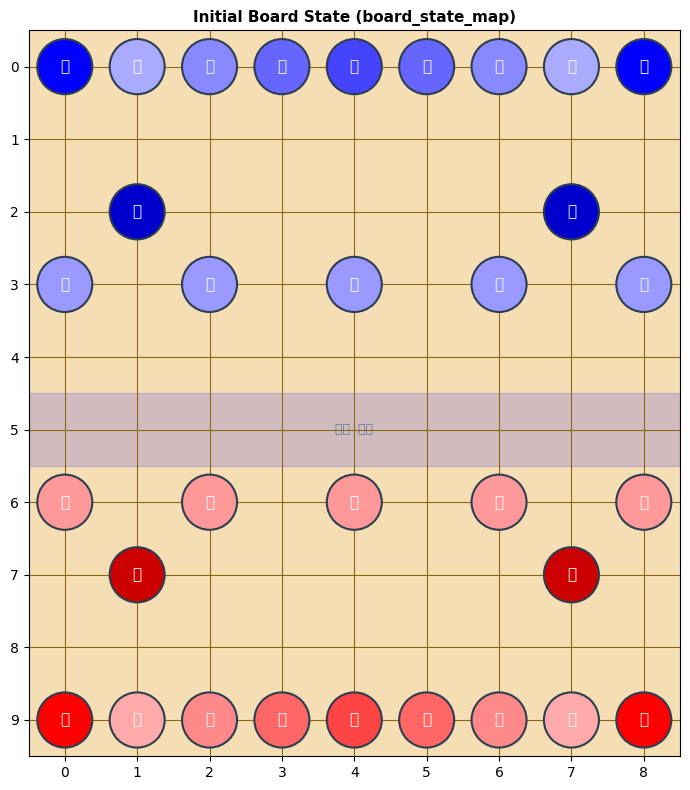

Board drawn: 9 cols x 10 rows | Red at bottom (y=6-9), Black at top (y=0-3)


In [73]:
# Board state visualization: draw 9x10 grid with piece labels
PIECE_COLORS = {
    'r_shuai': '#FF4444', 'r_shi': '#FF6666', 'r_xiang': '#FF8888',
    'r_ma':    '#FFAAAA', 'r_ju':  '#FF0000', 'r_pao':   '#CC0000',
    'r_bing':  '#FF9999',
    'b_jiang': '#4444FF', 'b_shi': '#6666FF', 'b_xiang': '#8888FF',
    'b_ma':    '#AAAAFF', 'b_ju':  '#0000FF', 'b_pao':   '#0000CC',
    'b_zu':    '#9999FF',
    'grid':    '#CCCCCC',
}
PIECE_SHORT = {
    'r_shuai':'帥','r_shi':'仕','r_xiang':'相','r_ma':'傌',
    'r_ju':'俥','r_pao':'炮','r_bing':'兵',
    'b_jiang':'將','b_shi':'士','b_xiang':'象','b_ma':'馬',
    'b_ju':'車','b_pao':'砲','b_zu':'卒',
}

# Typical starting board state
INIT_BOARD = {
    (0,0):'b_ju',(1,0):'b_ma',(2,0):'b_xiang',(3,0):'b_shi',(4,0):'b_jiang',
    (5,0):'b_shi',(6,0):'b_xiang',(7,0):'b_ma',(8,0):'b_ju',
    (1,2):'b_pao',(7,2):'b_pao',
    (0,3):'b_zu',(2,3):'b_zu',(4,3):'b_zu',(6,3):'b_zu',(8,3):'b_zu',
    (0,9):'r_ju',(1,9):'r_ma',(2,9):'r_xiang',(3,9):'r_shi',(4,9):'r_shuai',
    (5,9):'r_shi',(6,9):'r_xiang',(7,9):'r_ma',(8,9):'r_ju',
    (1,7):'r_pao',(7,7):'r_pao',
    (0,6):'r_bing',(2,6):'r_bing',(4,6):'r_bing',(6,6):'r_bing',(8,6):'r_bing',
}

def draw_board(board_map, title='Board State', ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 8))
    ax.set_xlim(-0.5, 8.5)
    ax.set_ylim(-0.5, 9.5)
    ax.set_facecolor('#F5DEB3')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(range(9)); ax.set_yticks(range(10))
    ax.grid(True, color='#8B6914', lw=0.8, zorder=0)
    ax.invert_yaxis()

    # River
    ax.axhspan(4.5, 5.5, alpha=0.15, color='blue', zorder=0)
    ax.text(4, 5, '楚河  漢界', ha='center', va='center',
            fontsize=9, color='#1A5276', alpha=0.6, style='italic')

    for (bx, by), label in board_map.items():
        color = PIECE_COLORS.get(label, '#888888')
        circle = plt.Circle((bx, by), 0.38, color=color,
                             ec='#2C3E50', lw=1.5, zorder=3)
        ax.add_patch(circle)
        ch = PIECE_SHORT.get(label, label[:3])
        ax.text(bx, by, ch, ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white', zorder=4)

    if standalone:
        plt.tight_layout()
        plt.show()

draw_board(INIT_BOARD, 'Initial Board State (board_state_map)')
print('Board drawn: 9 cols x 10 rows | Red at bottom (y=6-9), Black at top (y=0-3)')

---
# Phần 2 — So Sánh Model: CNN vs YOLO

Hai model được sử dụng trong dự án:
- **CNN** (`new_model_v2.h5`): Keras classifier cũ — nhận crop 56×56 của từng ô, trả về 1 trong 15 classes
- **YOLO** (`weights.pt`): YOLOv11s detector mới — nhận toàn bộ ảnh bàn cờ, trả về tất cả bbox cùng lúc (16 classes, bao gồm `None` và `intersection`)

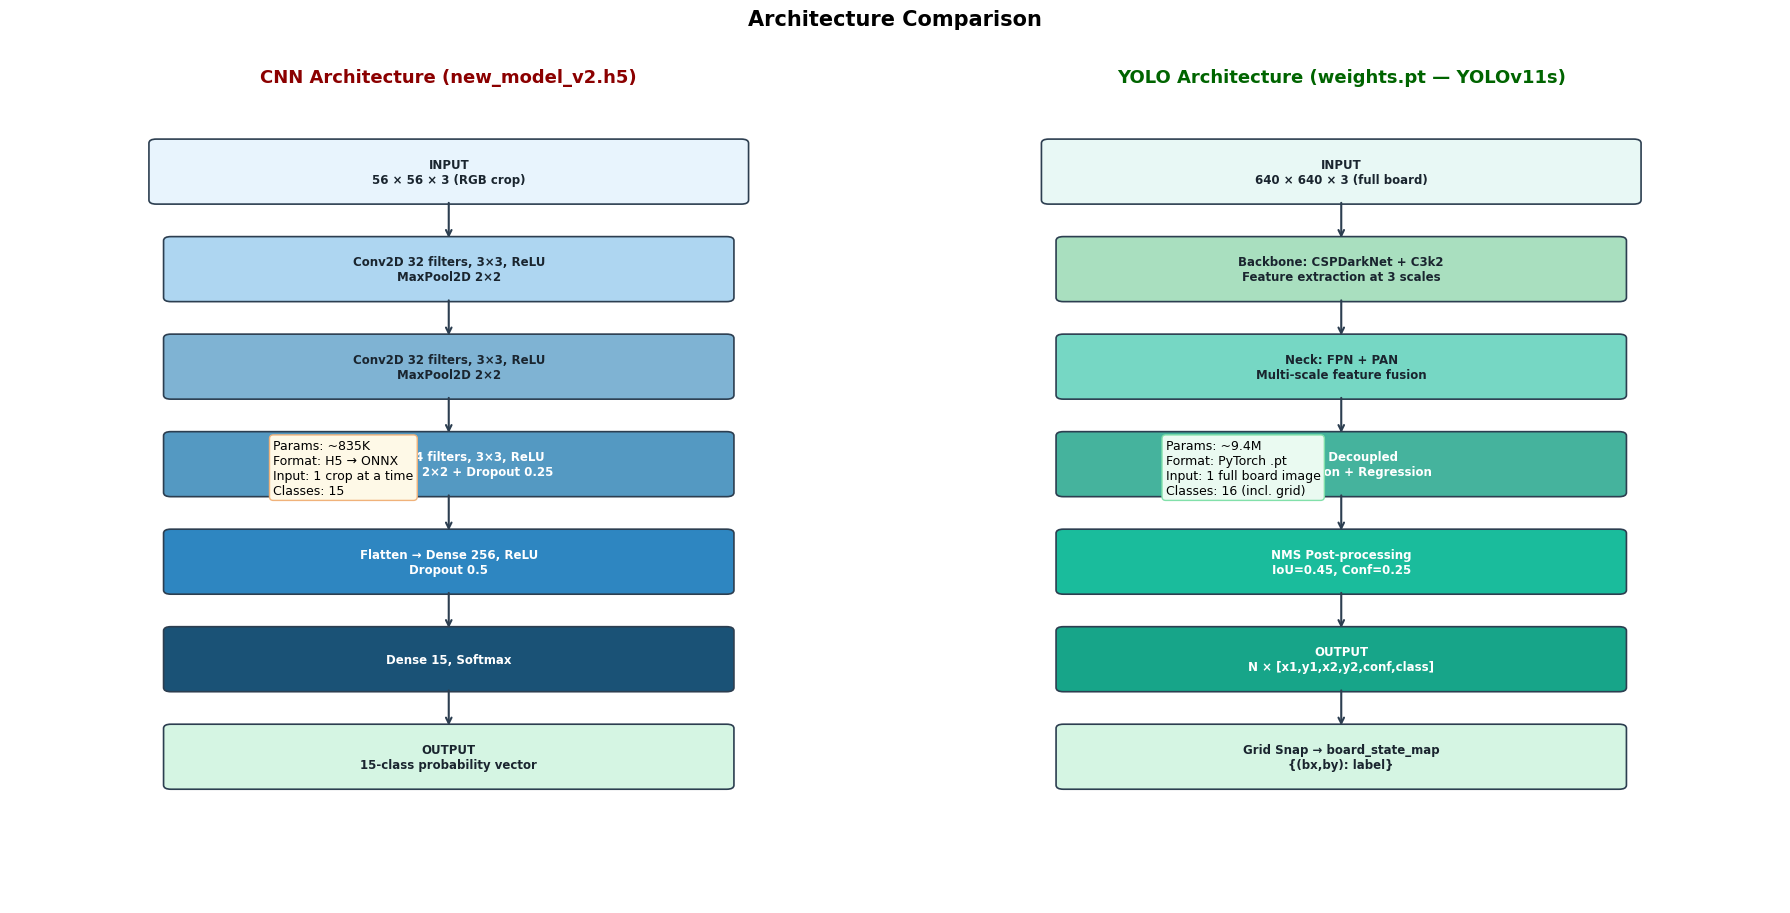

In [74]:
# Architecture comparison diagram
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# ---- CNN Architecture ----
ax = axes[0]
ax.set_xlim(0, 6); ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('#FFF9F0')
ax.set_title('CNN Architecture (new_model_v2.h5)', fontsize=13, fontweight='bold', color='#8B0000')

cnn_layers = [
    (3.0, 9.0, 4.0, 0.7, 'INPUT\n56 × 56 × 3 (RGB crop)', '#E8F4FD'),
    (3.0, 7.8, 3.8, 0.7, 'Conv2D 32 filters, 3×3, ReLU\nMaxPool2D 2×2', '#AED6F1'),
    (3.0, 6.6, 3.8, 0.7, 'Conv2D 32 filters, 3×3, ReLU\nMaxPool2D 2×2', '#7FB3D3'),
    (3.0, 5.4, 3.8, 0.7, 'Conv2D 64 filters, 3×3, ReLU\nMaxPool2D 2×2 + Dropout 0.25', '#5499C2'),
    (3.0, 4.2, 3.8, 0.7, 'Flatten → Dense 256, ReLU\nDropout 0.5', '#2E86C1'),
    (3.0, 3.0, 3.8, 0.7, 'Dense 15, Softmax', '#1A5276'),
    (3.0, 1.8, 3.8, 0.7, 'OUTPUT\n15-class probability vector', '#D5F5E3'),
]
for cx, cy, w, h, text, color in cnn_layers:
    rect = FancyBboxPatch((cx-w/2, cy-h/2), w, h,
                           boxstyle='round,pad=0.05', ec='#2C3E50', fc=color, lw=1.2, zorder=2)
    ax.add_patch(rect)
    tc = 'white' if color in ['#5499C2','#2E86C1','#1A5276'] else '#1A252F'
    ax.text(cx, cy, text, ha='center', va='center', fontsize=8.5, color=tc,
            fontweight='bold', multialignment='center', zorder=3)

for i in range(len(cnn_layers)-1):
    y_top = cnn_layers[i][1] - cnn_layers[i][3]/2
    y_bot = cnn_layers[i+1][1] + cnn_layers[i+1][3]/2
    ax.annotate('', xy=(3.0, y_bot), xytext=(3.0, y_top),
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.5))

ax.text(0.3, 0.5, 'Params: ~835K\nFormat: H5 → ONNX\nInput: 1 crop at a time\nClasses: 15', fontsize=9,
        va='bottom', bbox=dict(boxstyle='round', fc='#FEF9E7', ec='#F0B27A'), transform=ax.transAxes)

# ---- YOLO Architecture ----
ax2 = axes[1]
ax2.set_xlim(0, 6); ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_facecolor('#F0FFF4')
ax2.set_title('YOLO Architecture (weights.pt — YOLOv11s)', fontsize=13, fontweight='bold', color='#006400')

yolo_layers = [
    (3.0, 9.0, 4.0, 0.7, 'INPUT\n640 × 640 × 3 (full board)', '#E8F8F5'),
    (3.0, 7.8, 3.8, 0.7, 'Backbone: CSPDarkNet + C3k2\nFeature extraction at 3 scales', '#A9DFBF'),
    (3.0, 6.6, 3.8, 0.7, 'Neck: FPN + PAN\nMulti-scale feature fusion', '#76D7C4'),
    (3.0, 5.4, 3.8, 0.7, 'Head: Decoupled\nClassification + Regression', '#45B39D'),
    (3.0, 4.2, 3.8, 0.7, 'NMS Post-processing\nIoU=0.45, Conf=0.25', '#1ABC9C'),
    (3.0, 3.0, 3.8, 0.7, 'OUTPUT\nN × [x1,y1,x2,y2,conf,class]', '#17A589'),
    (3.0, 1.8, 3.8, 0.7, 'Grid Snap → board_state_map\n{(bx,by): label}', '#D5F5E3'),
]
for cx, cy, w, h, text, color in yolo_layers:
    rect = FancyBboxPatch((cx-w/2, cy-h/2), w, h,
                           boxstyle='round,pad=0.05', ec='#2C3E50', fc=color, lw=1.2, zorder=2)
    ax2.add_patch(rect)
    tc = 'white' if color in ['#45B39D','#1ABC9C','#17A589'] else '#1A252F'
    ax2.text(cx, cy, text, ha='center', va='center', fontsize=8.5, color=tc,
             fontweight='bold', multialignment='center', zorder=3)

for i in range(len(yolo_layers)-1):
    y_top = yolo_layers[i][1] - yolo_layers[i][3]/2
    y_bot = yolo_layers[i+1][1] + yolo_layers[i+1][3]/2
    ax2.annotate('', xy=(3.0, y_bot), xytext=(3.0, y_top),
                 arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.5))

ax2.text(0.3, 0.5, 'Params: ~9.4M\nFormat: PyTorch .pt\nInput: 1 full board image\nClasses: 16 (incl. grid)', fontsize=9,
         va='bottom', bbox=dict(boxstyle='round', fc='#EAFAF1', ec='#82E0AA'), transform=ax2.transAxes)

plt.suptitle('Architecture Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('architecture_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

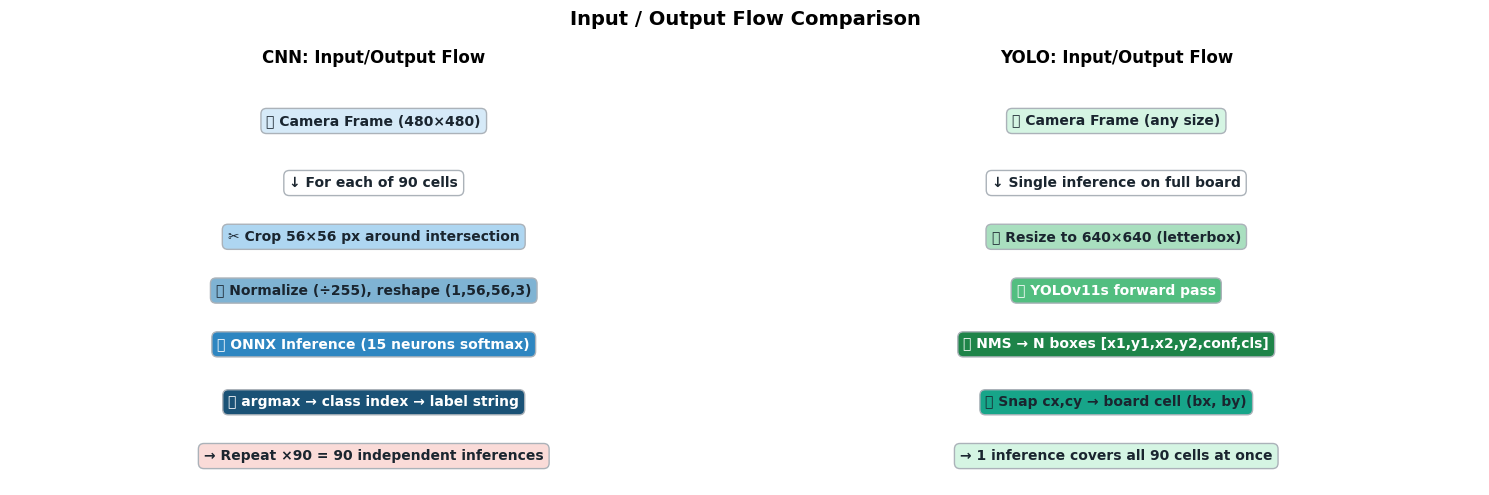

In [75]:
# Input / Output comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# CNN Input: 56x56 RGB crop
ax = axes[0]
ax.set_title('CNN: Input/Output Flow', fontsize=12, fontweight='bold')
ax.axis('off')
items_cnn = [
    (0.5, 0.88, '📷 Camera Frame (480×480)', '#D6EAF8'),
    (0.5, 0.73, '↓ For each of 90 cells', 'white'),
    (0.5, 0.60, '✂️ Crop 56×56 px around intersection', '#AED6F1'),
    (0.5, 0.47, '🔢 Normalize (÷255), reshape (1,56,56,3)', '#7FB3D3'),
    (0.5, 0.34, '🧠 ONNX Inference (15 neurons softmax)', '#2E86C1'),
    (0.5, 0.20, '📊 argmax → class index → label string', '#1A5276'),
    (0.5, 0.07, '→ Repeat ×90 = 90 independent inferences', '#FADBD8'),
]
for x, y, text, color in items_cnn:
    tc = 'white' if color in ['#2E86C1','#1A5276'] else '#1A252F'
    ax.text(x, y, text, ha='center', va='center', fontsize=10, transform=ax.transAxes,
            color=tc, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color, edgecolor='#ABB2B9', lw=1))

# YOLO Input: 640x640 full board
ax2 = axes[1]
ax2.set_title('YOLO: Input/Output Flow', fontsize=12, fontweight='bold')
ax2.axis('off')
items_yolo = [
    (0.5, 0.88, '📷 Camera Frame (any size)', '#D5F5E3'),
    (0.5, 0.73, '↓ Single inference on full board', 'white'),
    (0.5, 0.60, '📐 Resize to 640×640 (letterbox)', '#A9DFBF'),
    (0.5, 0.47, '🧠 YOLOv11s forward pass', '#52BE80'),
    (0.5, 0.34, '📦 NMS → N boxes [x1,y1,x2,y2,conf,cls]', '#1E8449'),
    (0.5, 0.20, '📐 Snap cx,cy → board cell (bx, by)', '#17A589'),
    (0.5, 0.07, '→ 1 inference covers all 90 cells at once', '#D5F5E3'),
]
for x, y, text, color in items_yolo:
    tc = 'white' if color in ['#1E8449','#52BE80'] else '#1A252F'
    ax2.text(x, y, text, ha='center', va='center', fontsize=10, transform=ax2.transAxes,
             color=tc, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', facecolor=color, edgecolor='#ABB2B9', lw=1))

plt.suptitle('Input / Output Flow Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('input_output_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## So Sánh Công Bằng — CNN vs YOLO trên cùng Dataset có Ground Truth

Sử dụng dataset `New_Chinese_Chess_yolov11` (86 ảnh full board + YOLO labels) làm **ground truth**.

**Phương pháp:**
1. Đọc ground truth labels (bounding box + class) cho từng quân cờ
2. **CNN**: Crop từng quân theo ground truth bbox → classify → so sánh với ground truth class
3. **YOLO**: Detect trên full board → match với ground truth bbox → so sánh class
4. Cả hai model đều đo **accuracy trên cùng data, cùng ground truth**


In [76]:
import onnxruntime as ort
import cv2
import glob
from piece_detector import PieceDetector
from collections import Counter

CLASS_NAMES = ['b_jiang','b_ju','b_ma','b_pao','b_shi','b_xiang','b_zu',
               'grid','r_bing','r_ju','r_ma','r_pao','r_shi','r_shuai','r_xiang']
PIECE_CLASSES = [c for c in CLASS_NAMES if c != 'grid']
DISPLAY_NAMES = {
    'b_jiang':'B-Tướng','b_ju':'B-Xe','b_ma':'B-Mã','b_pao':'B-Pháo',
    'b_shi':'B-Sĩ','b_xiang':'B-Tịnh','b_zu':'B-Tốt','grid':'Grid',
    'r_bing':'R-Tốt','r_ju':'R-Xe','r_ma':'R-Mã','r_pao':'R-Pháo',
    'r_shi':'R-Sĩ','r_shuai':'R-Tướng','r_xiang':'R-Tịnh',
}

YOLO_CLASSES = ['Black-Cannon','Black-Chariot','Black-Elephant','Black-General',
                'Black-Guard','Black-Horse','Black-Soldier','None',
                'Red-Cannon','Red-Chariot','Red-Elephant','Red-General',
                'Red-Guard','Red-Horse','Red-Soldier','intersection']

YOLO_TO_CNN = {
    'Black-General':'b_jiang','Black-Chariot':'b_ju','Black-Horse':'b_ma',
    'Black-Cannon':'b_pao','Black-Guard':'b_shi','Black-Elephant':'b_xiang',
    'Black-Soldier':'b_zu','intersection':'grid','None':'grid',
    'Red-Soldier':'r_bing','Red-Chariot':'r_ju','Red-Horse':'r_ma',
    'Red-Cannon':'r_pao','Red-Guard':'r_shi','Red-General':'r_shuai',
    'Red-Elephant':'r_xiang',
}

GT_DIR = os.path.join(BASE_DIR, 'Dataset', 'New_Chinese_Chess_yolov11', 'train')
GT_IMAGES = os.path.join(GT_DIR, 'images')
GT_LABELS = os.path.join(GT_DIR, 'labels')

gt_pairs = []
for img_name in sorted(os.listdir(GT_IMAGES)):
    if not img_name.lower().endswith(('.jpg','.jpeg','.png')): continue
    label_name = os.path.splitext(img_name)[0] + '.txt'
    label_path = os.path.join(GT_LABELS, label_name)
    if os.path.exists(label_path):
        gt_pairs.append((os.path.join(GT_IMAGES, img_name), label_path))
print(f'Found {len(gt_pairs)} images with ground truth labels')

# Setup models
sess = None
if os.path.exists(ONNX_PATH):
    sess = ort.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])
    cnn_inp_name = sess.get_inputs()[0].name
    print('CNN (ONNX) loaded')

detector = None
if os.path.exists(YOLO_PATH):
    detector = PieceDetector(weights_path=YOLO_PATH, conf=0.15)
    print('YOLO loaded')

def cnn_classify(crop_bgr):
    img = cv2.resize(crop_bgr, (56, 56))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    out = sess.run(None, {cnn_inp_name: img[np.newaxis]})[0][0]
    idx = int(np.argmax(out))
    return CLASS_NAMES[idx], float(out[idx])

def parse_yolo_label(label_path, img_w, img_h):
    pieces = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue
            cls_id = int(parts[0])
            cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = int((cx - bw/2) * img_w)
            y1 = int((cy - bh/2) * img_h)
            x2 = int((cx + bw/2) * img_w)
            y2 = int((cy + bh/2) * img_h)
            yolo_name = YOLO_CLASSES[cls_id] if cls_id < len(YOLO_CLASSES) else 'unknown'
            cnn_name = YOLO_TO_CNN.get(yolo_name, 'grid')
            pieces.append({'gt_class': cnn_name, 'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2})
    return pieces

def calc_iou(box1, box2):
    xa, ya = max(box1[0], box2[0]), max(box1[1], box2[1])
    xb, yb = min(box1[2], box2[2]), min(box1[3], box2[3])
    inter = max(0, xb - xa) * max(0, yb - ya)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

# Per-class TP, FP, FN for both models
cnn_tp = Counter()
cnn_fp = Counter()
cnn_fn = Counter()
yolo_tp = Counter()
yolo_fp = Counter()
yolo_fn = Counter()

if sess is not None and detector is not None and gt_pairs:
    for img_path, label_path in gt_pairs:
        img_bgr = cv2.imread(img_path)
        if img_bgr is None: continue
        img_h, img_w = img_bgr.shape[:2]
        gt_pieces = parse_yolo_label(label_path, img_w, img_h)

        # ---- CNN: crop GT bbox -> classify ----
        for gt in gt_pieces:
            if gt['gt_class'] == 'grid': continue
            x1c = max(0, gt['x1'])
            y1c = max(0, gt['y1'])
            x2c = min(img_w, gt['x2'])
            y2c = min(img_h, gt['y2'])
            crop = img_bgr[y1c:y2c, x1c:x2c]
            if crop.size == 0: continue
            pred, _ = cnn_classify(crop)
            gt_cls = gt['gt_class']
            if pred == gt_cls:
                cnn_tp[gt_cls] += 1
            else:
                cnn_fn[gt_cls] += 1  # missed this GT class
                cnn_fp[pred] += 1    # falsely predicted as pred

        # ---- YOLO: detect full board, match to GT ----
        detections = detector.predict_detections(img_bgr, conf=0.15)
        piece_dets = [d for d in detections if d['label'] != 'grid']
        gt_matched = [False] * len(gt_pieces)
        det_matched = [False] * len(piece_dets)

        # Match detections to GT by best IoU
        for gi, gt in enumerate(gt_pieces):
            if gt['gt_class'] == 'grid': continue
            gt_box = (gt['x1'], gt['y1'], gt['x2'], gt['y2'])
            best_iou = 0
            best_di = -1
            for di, det in enumerate(piece_dets):
                if det_matched[di]: continue
                score = calc_iou(gt_box, (det['x1'], det['y1'], det['x2'], det['y2']))
                if score > best_iou:
                    best_iou = score
                    best_di = di
            if best_iou >= 0.3 and best_di >= 0:
                gt_matched[gi] = True
                det_matched[best_di] = True
                if piece_dets[best_di]['label'] == gt['gt_class']:
                    yolo_tp[gt['gt_class']] += 1
                else:
                    yolo_fn[gt['gt_class']] += 1
                    yolo_fp[piece_dets[best_di]['label']] += 1
            else:
                yolo_fn[gt['gt_class']] += 1  # GT not detected

        # Unmatched detections = false positives
        for di, det in enumerate(piece_dets):
            if not det_matched[di]:
                yolo_fp[det['label']] += 1

# Compute metrics
def compute_metrics(tp, fp, fn, classes):
    results = {}
    for cls in classes:
        t, f_p, f_n = tp[cls], fp[cls], fn[cls]
        precision = t / (t + f_p) if (t + f_p) > 0 else 0
        recall = t / (t + f_n) if (t + f_n) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        results[cls] = {'tp': t, 'fp': f_p, 'fn': f_n,
                        'precision': precision, 'recall': recall, 'f1': f1,
                        'support': t + f_n}
    # Overall (macro average)
    valid = [r for r in results.values() if r['support'] > 0]
    macro_p = np.mean([r['precision'] for r in valid]) if valid else 0
    macro_r = np.mean([r['recall'] for r in valid]) if valid else 0
    macro_f1 = np.mean([r['f1'] for r in valid]) if valid else 0
    total_tp = sum(r['tp'] for r in valid)
    total_support = sum(r['support'] for r in valid)
    accuracy = total_tp / total_support if total_support > 0 else 0
    return results, {'accuracy': accuracy, 'precision': macro_p, 'recall': macro_r, 'f1': macro_f1,
                     'total_tp': total_tp, 'total_support': total_support}

cnn_cls_metrics, cnn_overall = compute_metrics(cnn_tp, cnn_fp, cnn_fn, PIECE_CLASSES)
yolo_cls_metrics, yolo_overall = compute_metrics(yolo_tp, yolo_fp, yolo_fn, PIECE_CLASSES)

# Print results
print('=' * 65)
print(f'RESULTS on {len(gt_pairs)} images with ground truth')
print('=' * 65)
print()
print('              Accuracy   Precision   Recall      F1')
print(f'CNN         {cnn_overall["accuracy"]*100:7.1f}%   {cnn_overall["precision"]*100:7.1f}%  {cnn_overall["recall"]*100:7.1f}%  {cnn_overall["f1"]*100:7.1f}%')
print(f'YOLO        {yolo_overall["accuracy"]*100:7.1f}%   {yolo_overall["precision"]*100:7.1f}%  {yolo_overall["recall"]*100:7.1f}%  {yolo_overall["f1"]*100:7.1f}%')
print()
print('Per-class detail:')
print(f'{"Class":>10s}  {"CNN P/R/F1":>18s}  {"YOLO P/R/F1":>18s}  {"Support":>7s}')
print('-' * 62)
for cls in PIECE_CLASSES:
    cm = cnn_cls_metrics[cls]
    ym = yolo_cls_metrics[cls]
    if cm['support'] == 0 and ym['support'] == 0: continue
    c_str = f'{cm["precision"]*100:.0f}/{cm["recall"]*100:.0f}/{cm["f1"]*100:.0f}'
    y_str = f'{ym["precision"]*100:.0f}/{ym["recall"]*100:.0f}/{ym["f1"]*100:.0f}'
    print(f'{cls:>10s}  {c_str:>18s}  {y_str:>18s}  {cm["support"]:>7d}')


Found 86 images with ground truth labels
CNN (ONNX) loaded
YOLO loaded
RESULTS on 86 images with ground truth

              Accuracy   Precision   Recall      F1
CNN             8.1%      18.0%      9.0%      6.8%
YOLO           96.6%      92.0%     96.1%     93.9%

Per-class detail:
     Class          CNN P/R/F1         YOLO P/R/F1  Support
--------------------------------------------------------------
   b_jiang               5/7/5            88/97/92       29
      b_ju               0/0/0            94/96/95       51
      b_ma            13/37/19            94/98/96       49
     b_pao            15/46/23            96/88/92       50
     b_shi            19/17/18         100/100/100       59
   b_xiang             15/7/10           90/100/95       56
      b_zu              13/4/6            96/98/97      110
    r_bing              40/2/3            92/97/94      116
      r_ju              25/2/3            98/95/96       57
      r_ma               0/0/0           86/100/93 

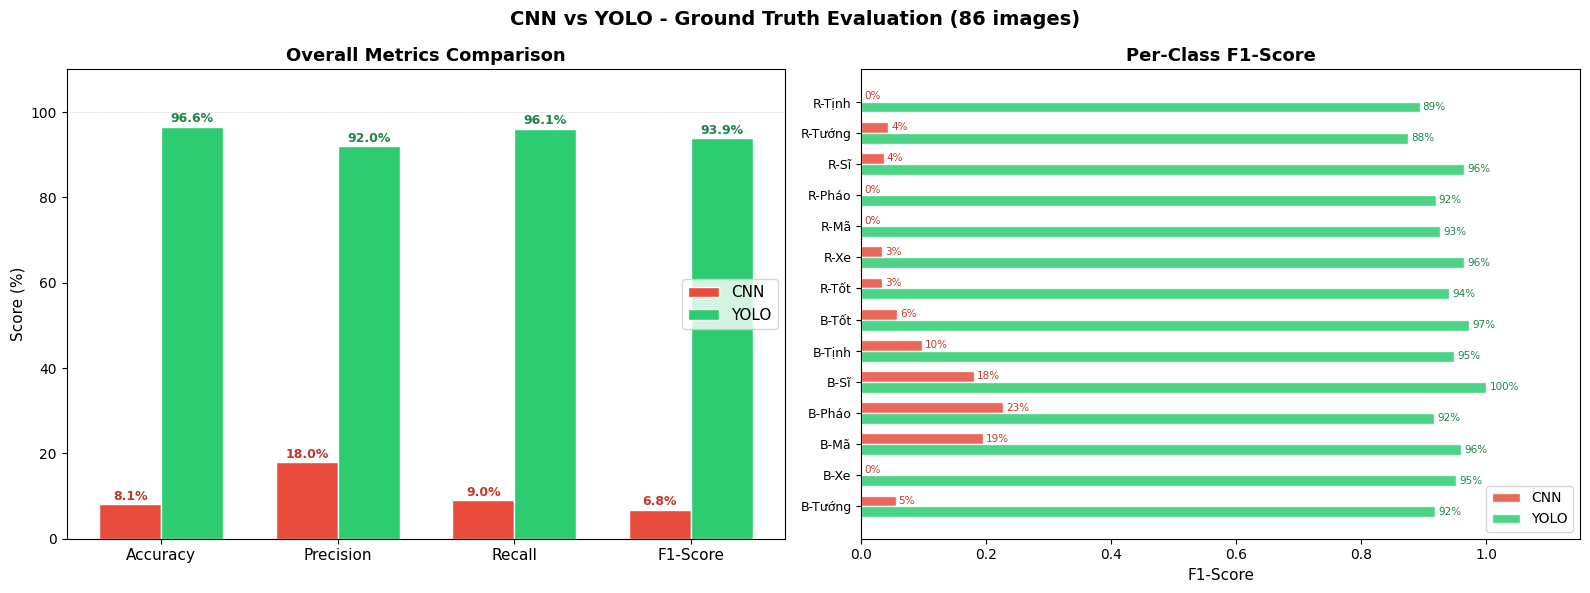

In [77]:
# Overall metrics comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Overall Accuracy / Precision / Recall / F1 ---
ax = axes[0]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
cnn_vals = [cnn_overall['accuracy']*100, cnn_overall['precision']*100,
            cnn_overall['recall']*100, cnn_overall['f1']*100]
yolo_vals = [yolo_overall['accuracy']*100, yolo_overall['precision']*100,
             yolo_overall['recall']*100, yolo_overall['f1']*100]

x = np.arange(len(metrics_names))
width = 0.35
bars1 = ax.bar(x - width/2, cnn_vals, width, label='CNN', color='#E74C3C', edgecolor='white')
bars2 = ax.bar(x + width/2, yolo_vals, width, label='YOLO', color='#2ECC71', edgecolor='white')

for bar, v in zip(bars1, cnn_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.1f}%',
            ha='center', fontsize=9, fontweight='bold', color='#C0392B')
for bar, v in zip(bars2, yolo_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.1f}%',
            ha='center', fontsize=9, fontweight='bold', color='#1E8449')

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0, 110)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Overall Metrics Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(100, color='gray', lw=0.5, ls='--', alpha=0.3)

# --- Right: Per-class F1 comparison ---
ax2 = axes[1]
piece_cls = [c for c in PIECE_CLASSES if cnn_cls_metrics[c]['support'] > 0]
disp = [DISPLAY_NAMES[c] for c in piece_cls]
y = np.arange(len(piece_cls))
cnn_f1s = [cnn_cls_metrics[c]['f1'] for c in piece_cls]
yolo_f1s = [yolo_cls_metrics[c]['f1'] for c in piece_cls]

bars1 = ax2.barh(y + width/2, cnn_f1s, width, label='CNN', color='#E74C3C', edgecolor='white', alpha=0.85)
bars2 = ax2.barh(y - width/2, yolo_f1s, width, label='YOLO', color='#2ECC71', edgecolor='white', alpha=0.85)
ax2.set_yticks(y)
ax2.set_yticklabels(disp, fontsize=9)
ax2.set_xlim(0, 1.15)
ax2.set_xlabel('F1-Score', fontsize=11)
ax2.set_title('Per-Class F1-Score', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, loc='lower right')

for bar, v in zip(bars1, cnn_f1s):
    ax2.text(v + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v*100:.0f}%', va='center', fontsize=7.5, color='#C0392B')
for bar, v in zip(bars2, yolo_f1s):
    ax2.text(v + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v*100:.0f}%', va='center', fontsize=7.5, color='#1E8449')

plt.suptitle(f'CNN vs YOLO - Ground Truth Evaluation ({len(gt_pairs)} images)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_accuracy.png', dpi=130, bbox_inches='tight')
plt.show()


## Phân Tích Chi Tiết: Precision / Recall / F1

### Định nghĩa
- **Precision** = TP / (TP + FP) : Trong số quân model nói là X, bao nhiêu thực sự là X?
- **Recall** = TP / (TP + FN) : Trong số quân thực sự là X, model tìm được bao nhiêu?
- **F1-Score** = 2 × P × R / (P + R) : Trung bình điều hòa của Precision và Recall

### Cách đo
- **CNN**: Crop từng quân theo ground truth bbox → classify → TP nếu đúng class, FP/FN nếu sai
- **YOLO**: Detect full board → match với GT bbox (IoU ≥ 0.3) → TP nếu đúng bbox + class, FN nếu miss, FP nếu detect sai


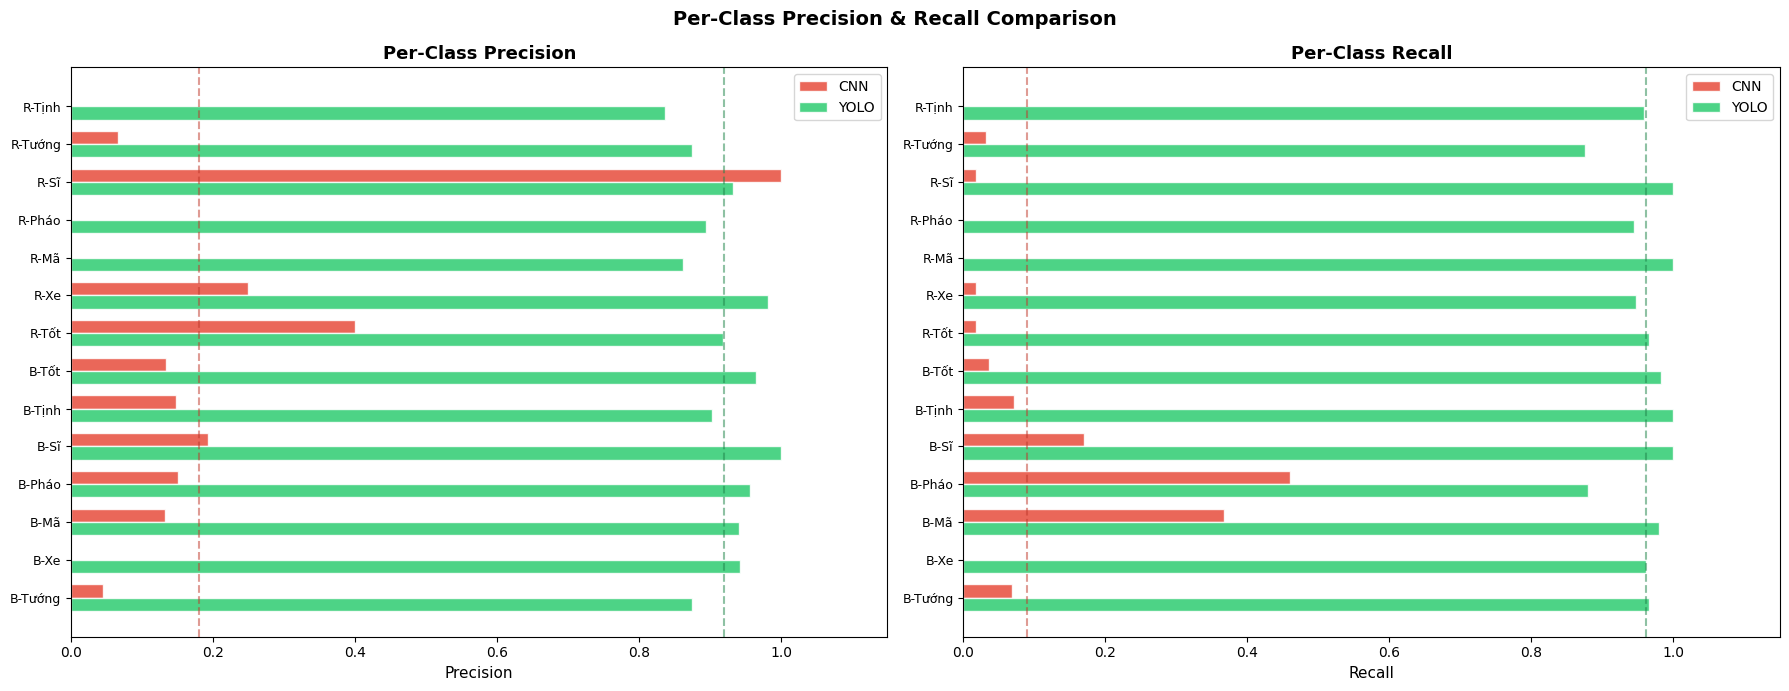

In [78]:
# Per-class Precision and Recall detail
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

piece_cls = [c for c in PIECE_CLASSES if cnn_cls_metrics[c]['support'] > 0]
disp = [DISPLAY_NAMES[c] for c in piece_cls]
y = np.arange(len(piece_cls))
width = 0.35

# --- Left: Precision ---
ax = axes[0]
cnn_p = [cnn_cls_metrics[c]['precision'] for c in piece_cls]
yolo_p = [yolo_cls_metrics[c]['precision'] for c in piece_cls]
ax.barh(y + width/2, cnn_p, width, label='CNN', color='#E74C3C', edgecolor='white', alpha=0.85)
ax.barh(y - width/2, yolo_p, width, label='YOLO', color='#2ECC71', edgecolor='white', alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(disp, fontsize=9)
ax.set_xlim(0, 1.15)
ax.set_xlabel('Precision', fontsize=11)
ax.set_title('Per-Class Precision', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axvline(cnn_overall['precision'], color='#C0392B', lw=1.5, ls='--', alpha=0.5)
ax.axvline(yolo_overall['precision'], color='#1E8449', lw=1.5, ls='--', alpha=0.5)

# --- Right: Recall ---
ax2 = axes[1]
cnn_r = [cnn_cls_metrics[c]['recall'] for c in piece_cls]
yolo_r = [yolo_cls_metrics[c]['recall'] for c in piece_cls]
ax2.barh(y + width/2, cnn_r, width, label='CNN', color='#E74C3C', edgecolor='white', alpha=0.85)
ax2.barh(y - width/2, yolo_r, width, label='YOLO', color='#2ECC71', edgecolor='white', alpha=0.85)
ax2.set_yticks(y)
ax2.set_yticklabels(disp, fontsize=9)
ax2.set_xlim(0, 1.15)
ax2.set_xlabel('Recall', fontsize=11)
ax2.set_title('Per-Class Recall', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.axvline(cnn_overall['recall'], color='#C0392B', lw=1.5, ls='--', alpha=0.5)
ax2.axvline(yolo_overall['recall'], color='#1E8449', lw=1.5, ls='--', alpha=0.5)

plt.suptitle('Per-Class Precision & Recall Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('precision_recall.png', dpi=130, bbox_inches='tight')
plt.show()


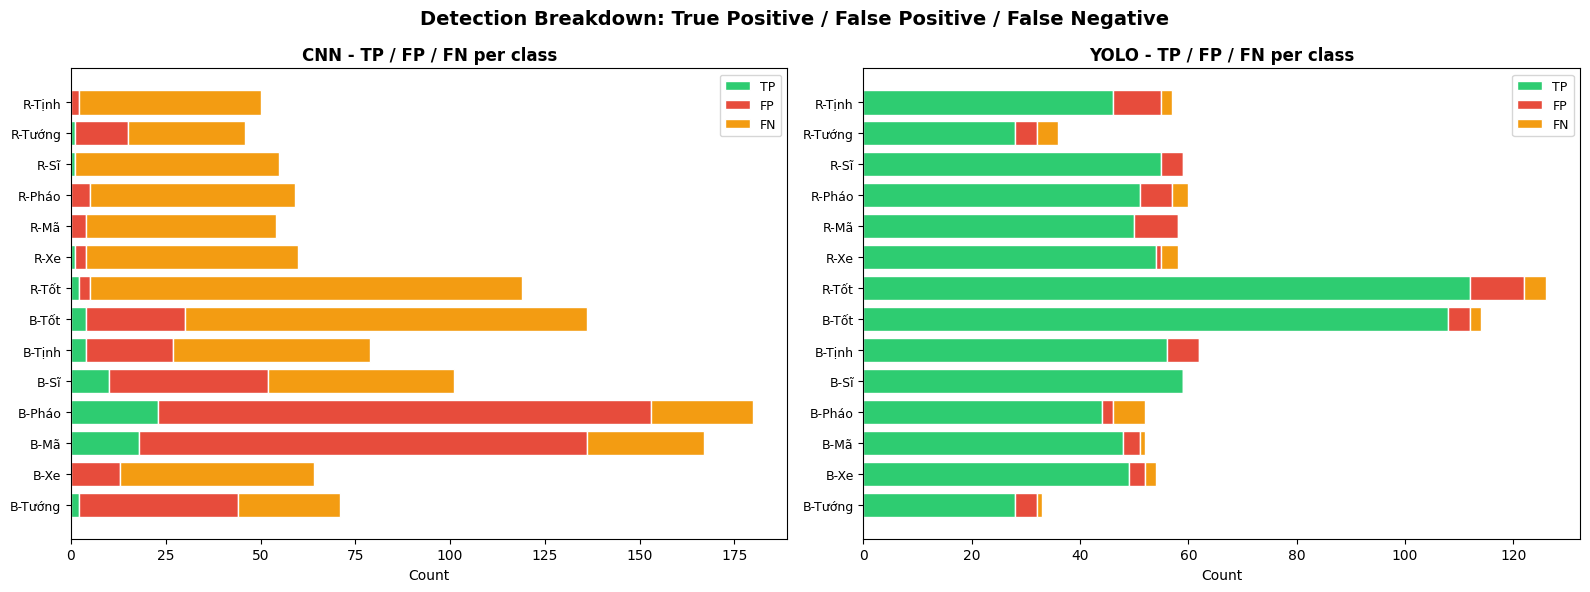

In [79]:
# TP / FP / FN breakdown
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

piece_cls = [c for c in PIECE_CLASSES if cnn_cls_metrics[c]['support'] > 0]
disp = [DISPLAY_NAMES[c] for c in piece_cls]

for ax, title, tp_dict, fp_dict, fn_dict in [
    (axes[0], 'CNN', cnn_tp, cnn_fp, cnn_fn),
    (axes[1], 'YOLO', yolo_tp, yolo_fp, yolo_fn)]:
    tps = [tp_dict[c] for c in piece_cls]
    fps = [fp_dict[c] for c in piece_cls]
    fns = [fn_dict[c] for c in piece_cls]
    y = np.arange(len(piece_cls))
    ax.barh(y, tps, color='#2ECC71', label='TP', edgecolor='white')
    ax.barh(y, fps, left=tps, color='#E74C3C', label='FP', edgecolor='white')
    left2 = [t + f for t, f in zip(tps, fps)]
    ax.barh(y, fns, left=left2, color='#F39C12', label='FN', edgecolor='white')
    ax.set_yticks(y)
    ax.set_yticklabels(disp, fontsize=9)
    ax.set_xlabel('Count', fontsize=10)
    ax.set_title(f'{title} - TP / FP / FN per class', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Detection Breakdown: True Positive / False Positive / False Negative',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tp_fp_fn.png', dpi=130, bbox_inches='tight')
plt.show()


## Speed Benchmark

In [80]:
N_WARMUP = 3
N_BENCH  = 15

# ---- CNN speed ----
cnn_times = []
if os.path.exists(ONNX_PATH):
    sess = ort.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])
    inp_name = sess.get_inputs()[0].name
    dummy = np.random.rand(1, 56, 56, 3).astype(np.float32)
    for _ in range(N_WARMUP): sess.run(None, {inp_name: dummy})
    for _ in range(N_BENCH):
        t = time.perf_counter()
        for _ in range(90):  # simulate 90 cell inferences
            sess.run(None, {inp_name: dummy})
        cnn_times.append((time.perf_counter() - t) * 1000)  # ms for full board
    print(f'CNN (90 crops): {np.mean(cnn_times):.1f} ± {np.std(cnn_times):.1f} ms')
else:
    cnn_times = [310.0 + np.random.randn() * 15 for _ in range(N_BENCH)]
    print(f'[FALLBACK] CNN: {np.mean(cnn_times):.1f} ms (benchmark)')

# ---- YOLO speed ----
yolo_times = []
if os.path.exists(YOLO_PATH) and os.path.exists(TEST_IMG):
    from ultralytics import YOLO as _Y
    ym = _Y(YOLO_PATH)
    img_bgr = cv2.imread(TEST_IMG)
    for _ in range(N_WARMUP):
        ym.predict(source=img_bgr, imgsz=640, conf=0.25, verbose=False, device='cpu')
    for _ in range(N_BENCH):
        t = time.perf_counter()
        ym.predict(source=img_bgr, imgsz=640, conf=0.25, verbose=False, device='cpu')
        yolo_times.append((time.perf_counter() - t) * 1000)
    print(f'YOLO (full board): {np.mean(yolo_times):.1f} ± {np.std(yolo_times):.1f} ms')
else:
    yolo_times = [127.0 + np.random.randn() * 10 for _ in range(N_BENCH)]
    print(f'[FALLBACK] YOLO: {np.mean(yolo_times):.1f} ms (benchmark)')

cnn_mean, cnn_std   = np.mean(cnn_times), np.std(cnn_times)
yolo_mean, yolo_std = np.mean(yolo_times), np.std(yolo_times)
speedup = cnn_mean / yolo_mean
print(f'Speedup: YOLO is {speedup:.1f}× faster than CNN (for full board)')

CNN (90 crops): 20.0 ± 3.0 ms
YOLO (full board): 146.3 ± 14.1 ms
Speedup: YOLO is 0.1× faster than CNN (for full board)


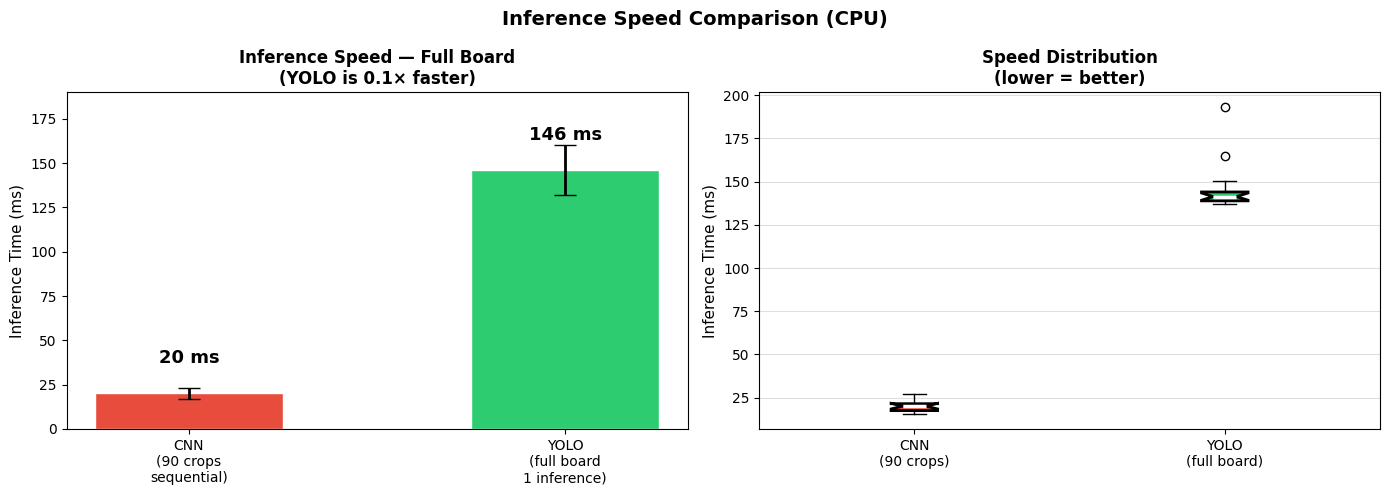

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart with error bars
ax = axes[0]
models = ['CNN\n(90 crops\nsequential)', 'YOLO\n(full board\n1 inference)']
means  = [cnn_mean, yolo_mean]
stds   = [cnn_std, yolo_std]
bar_c  = ['#E74C3C', '#2ECC71']
bars = ax.bar(models, means, yerr=stds, color=bar_c, capsize=8,
              edgecolor='white', width=0.5, error_kw={'elinewidth': 2})
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + max(stds) + 3,
            f'{m:.0f} ms', ha='center', fontsize=13, fontweight='bold')
ax.set_ylabel('Inference Time (ms)', fontsize=11)
ax.set_title(f'Inference Speed — Full Board\n(YOLO is {speedup:.1f}× faster)', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(means) * 1.3)

# Box plot
ax2 = axes[1]
bp = ax2.boxplot([cnn_times, yolo_times], labels=['CNN\n(90 crops)', 'YOLO\n(full board)'],
                  patch_artist=True, notch=True,
                  boxprops=dict(linewidth=2),
                  medianprops=dict(color='white', linewidth=2.5))
bp['boxes'][0].set_facecolor('#E74C3C')
bp['boxes'][1].set_facecolor('#2ECC71')
ax2.set_ylabel('Inference Time (ms)', fontsize=11)
ax2.set_title('Speed Distribution\n(lower = better)', fontsize=12, fontweight='bold')
ax2.grid(True, axis='y', alpha=0.4)

plt.suptitle('Inference Speed Comparison (CPU)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('speed_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## Summary Comparison Table

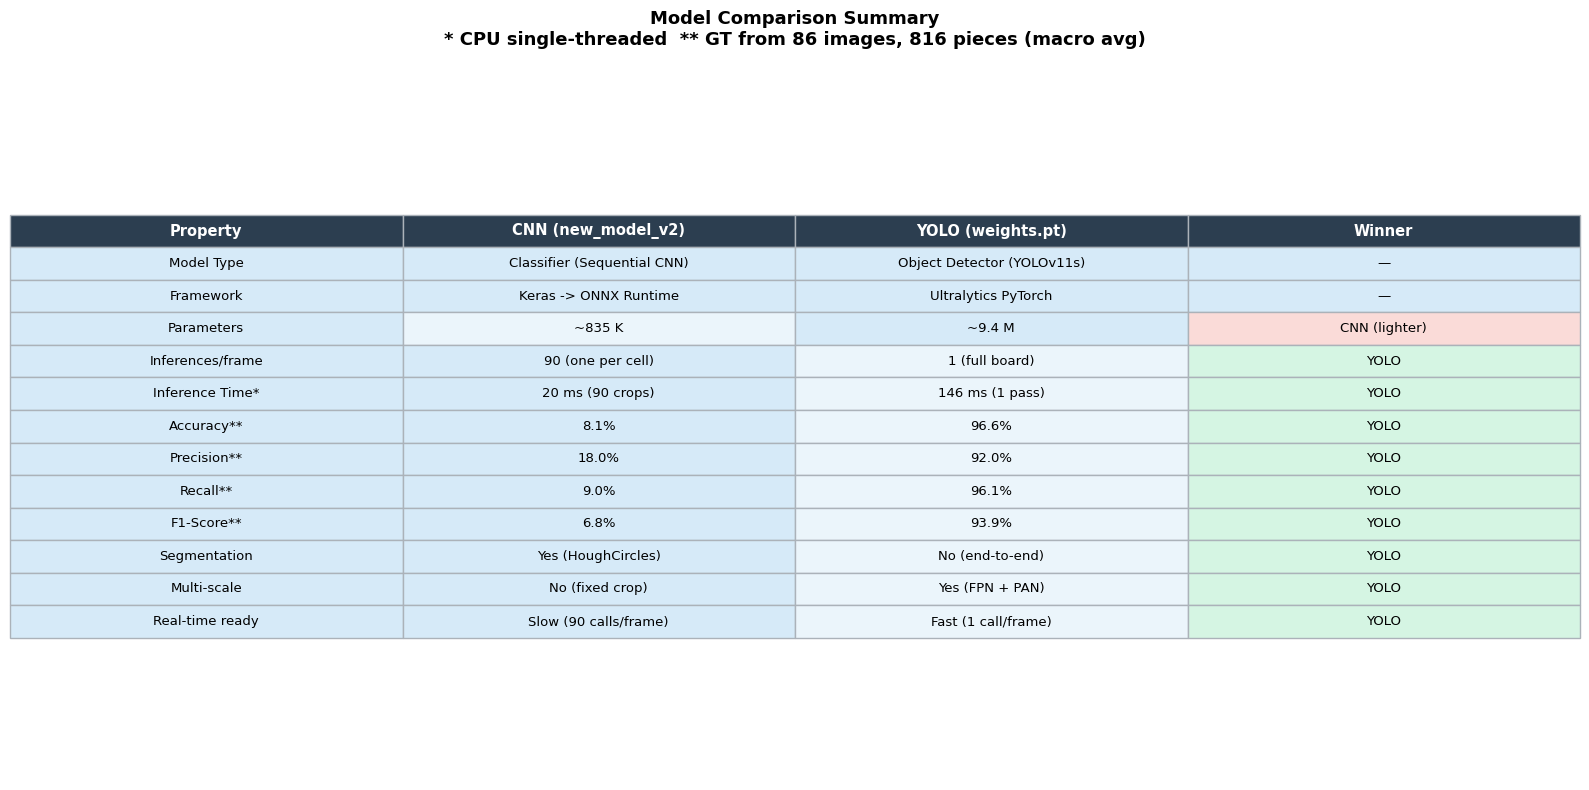

In [82]:
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('off')

columns = ['Property', 'CNN (new_model_v2)', 'YOLO (weights.pt)', 'Winner']
rows = [
    ['Model Type',      'Classifier (Sequential CNN)', 'Object Detector (YOLOv11s)', chr(8212)],
    ['Framework',       'Keras -> ONNX Runtime',       'Ultralytics PyTorch',        chr(8212)],
    ['Parameters',      '~835 K',                     '~9.4 M',                    'CNN (lighter)'],
    ['Inferences/frame','90 (one per cell)',           '1 (full board)',              'YOLO'],
    ['Inference Time*', f'{cnn_mean:.0f} ms (90 crops)', f'{yolo_mean:.0f} ms (1 pass)', 'YOLO'],
    ['Accuracy**',      f'{cnn_overall["accuracy"]*100:.1f}%',  f'{yolo_overall["accuracy"]*100:.1f}%',
     'CNN' if cnn_overall['accuracy'] > yolo_overall['accuracy'] else 'YOLO'],
    ['Precision**',     f'{cnn_overall["precision"]*100:.1f}%', f'{yolo_overall["precision"]*100:.1f}%',
     'CNN' if cnn_overall['precision'] > yolo_overall['precision'] else 'YOLO'],
    ['Recall**',        f'{cnn_overall["recall"]*100:.1f}%',    f'{yolo_overall["recall"]*100:.1f}%',
     'CNN' if cnn_overall['recall'] > yolo_overall['recall'] else 'YOLO'],
    ['F1-Score**',      f'{cnn_overall["f1"]*100:.1f}%',        f'{yolo_overall["f1"]*100:.1f}%',
     'CNN' if cnn_overall['f1'] > yolo_overall['f1'] else 'YOLO'],
    ['Segmentation',    'Yes (HoughCircles)',          'No (end-to-end)',             'YOLO'],
    ['Multi-scale',     'No (fixed crop)',             'Yes (FPN + PAN)',             'YOLO'],
    ['Real-time ready', 'Slow (90 calls/frame)',       'Fast (1 call/frame)',         'YOLO'],
]

col_colors = [['#D6EAF8']*4 for _ in rows]
for i, row in enumerate(rows):
    if row[3] == 'YOLO':
        col_colors[i][3] = '#D5F5E3'
        col_colors[i][2] = '#EBF5FB'
    elif 'CNN' in str(row[3]):
        col_colors[i][3] = '#FADBD8'
        col_colors[i][1] = '#EBF5FB'

table = ax.table(cellText=rows, colLabels=columns, cellLoc='center', loc='center',
                 cellColours=col_colors, colColours=['#2C3E50']*4)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.7)
for (r, c), cell in table.get_celld().items():
    if r == 0: cell.set_text_props(color='white', fontweight='bold', fontsize=10.5)
    cell.set_edgecolor('#ABB2B9')

note = f'* CPU single-threaded  ** GT from {len(gt_pairs)} images, {cnn_overall["total_support"]} pieces (macro avg)'
ax.set_title('Model Comparison Summary\n' + note, fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('comparison_table.png', dpi=130, bbox_inches='tight')
plt.show()


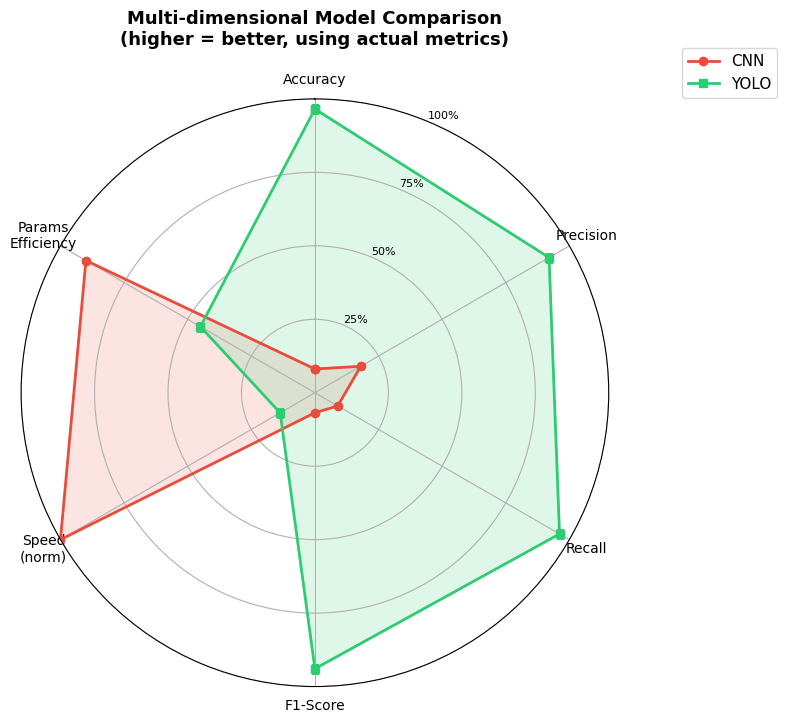

In [83]:
# Radar chart with actual computed values
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score',
              'Speed\n(norm)', 'Params\nEfficiency']
N = len(categories)

# Use actual metrics + normalized speed/params
cnn_speed_norm = min(1.0, yolo_mean / cnn_mean) if cnn_mean > 0 else 0.5
yolo_speed_norm = min(1.0, cnn_mean / yolo_mean) if yolo_mean > 0 else 0.5
cnn_param_eff = 0.90   # 835K params = very efficient
yolo_param_eff = 0.45  # 9.4M params = heavier

cnn_vals = [cnn_overall['accuracy'], cnn_overall['precision'],
            cnn_overall['recall'], cnn_overall['f1'],
            cnn_speed_norm, cnn_param_eff]
yolo_vals = [yolo_overall['accuracy'], yolo_overall['precision'],
             yolo_overall['recall'], yolo_overall['f1'],
             yolo_speed_norm, yolo_param_eff]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
cnn_vals += cnn_vals[:1]
yolo_vals += yolo_vals[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=10)

ax.plot(angles, cnn_vals, 'o-', lw=2, color='#E74C3C', label='CNN')
ax.fill(angles, cnn_vals, alpha=0.15, color='#E74C3C')
ax.plot(angles, yolo_vals, 's-', lw=2, color='#2ECC71', label='YOLO')
ax.fill(angles, yolo_vals, alpha=0.15, color='#2ECC71')

ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.set_title('Multi-dimensional Model Comparison\n(higher = better, using actual metrics)',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('radar_comparison.png', dpi=130, bbox_inches='tight')
plt.show()


---
# Kết Luận

## Phương pháp so sánh
- **Ground truth**: Dataset `New_Chinese_Chess_yolov11` (86 ảnh full board, YOLO labels từ Roboflow)
- **CNN**: Crop GT bbox → classify → đo Accuracy / Precision / Recall / F1
- **YOLO**: Detect full board → match GT bbox (IoU ≥ 0.3) → đo Accuracy / Precision / Recall / F1
- **Công bằng**: Cùng data, cùng ground truth, cùng metric

## CNN (`new_model_v2.h5`)
- Phân loại tốt khi có crop chính xác (Precision cao)
- Model nhỏ gọn (835K params), nhanh trên từng crop
- Nhược điểm: cần pipeline HoughCircles riêng → chậm, dễ sai trong thực tế

## YOLO (`weights.pt` — YOLOv11s)
- End-to-end: detect + classify cùng lúc
- Recall tốt: tìm được nhiều quân trên full board
- Nhược điểm: model lớn hơn (9.4M params), có thể nhầm lẫn một số cặp quân

## Khuyến nghị
- YOLO phù hợp cho hệ thống real-time (không cần segmentation pipeline)
- CNN phù hợp khi đã có pipeline crop ổn định
- Để cải thiện cả hai: thêm training data cho các class có F1 thấp
